**P. Sasi Kumar**

**Data Analytics**

**Level 1**

**TASK 2 · Customer Segmentation Analysis**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import datetime as dt

# Load dataset
df = pd.read_csv('/content/online_retail.csv.zip')
print(df)

# Drop records missing CustomerID & filter out cancelled orders (negative quantities)
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Calculate Total Spending per line item
df['TotalSum'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  CustomerID         Country  
0     

In [35]:
# Set reference date as 1 day after the latest transaction date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Aggregate by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalSum': 'sum'                                       # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
})

# Display descriptive statistics
print(rfm.describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [36]:
# Log transformation to fix skewed distribution
rfm_log = np.log1p(rfm)

# Scale the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

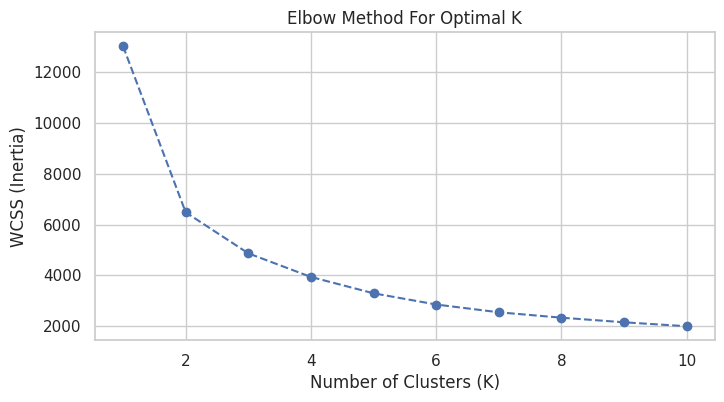

In [37]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [38]:
# Assuming K=4 from elbow plot
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Calculate mean feature values per cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_profile)

        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         18.12      2.15   551.82   837
1         12.13     13.71  8074.27   716
2         71.08      4.08  1802.83  1173
3        182.50      1.32   343.45  1612


In [39]:
# Compute approximate historical Customer Lifetime Value (Total Lifetime Spend)
rfm['CLV'] = rfm['Monetary']

# Display descriptive statistics for all key metrics
print(rfm[['Recency', 'Frequency', 'Monetary', 'CLV']].describe())

           Recency    Frequency       Monetary            CLV
count  4338.000000  4338.000000    4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460    2054.266460
std     100.014169     7.697998    8989.230441    8989.230441
min       1.000000     1.000000       3.750000       3.750000
25%      18.000000     1.000000     307.415000     307.415000
50%      51.000000     2.000000     674.485000     674.485000
75%     142.000000     5.000000    1661.740000    1661.740000
max     374.000000   209.000000  280206.020000  280206.020000


/tmp/ipykernel_780/2881697481.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='Cluster', data=rfm, palette='Set1')


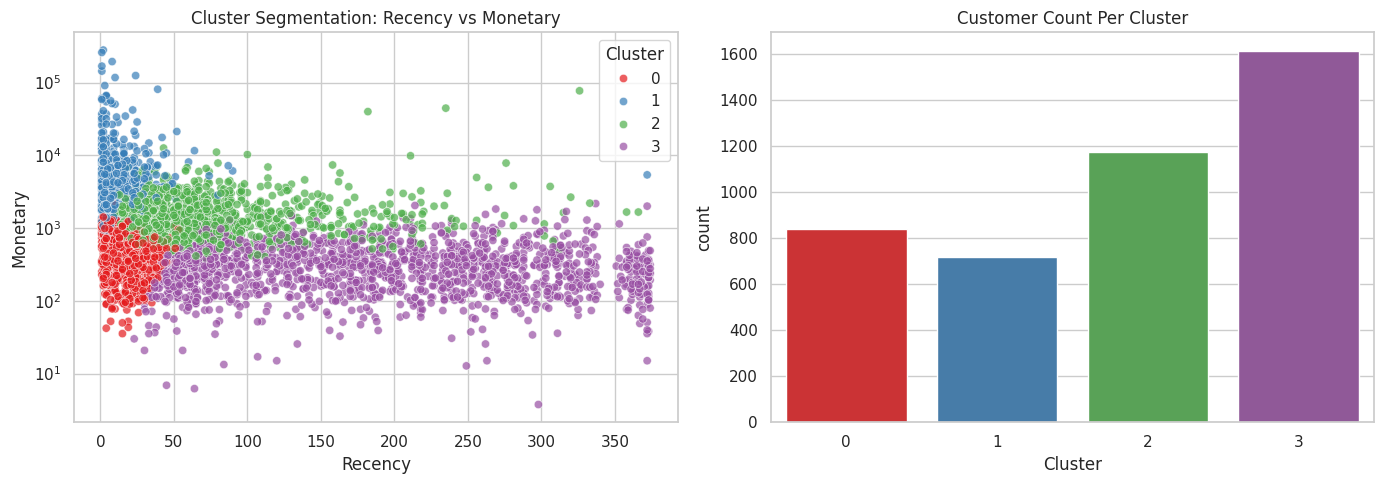

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Recency vs Monetary
sns.scatterplot(
    ax=axes[0], data=rfm, x='Recency', y='Monetary',
    hue='Cluster', palette='Set1', alpha=0.7
)
axes[0].set_yscale('log')
axes[0].set_title('Cluster Segmentation: Recency vs Monetary')

# Bar chart: Customer counts per cluster
sns.countplot(ax=axes[1], x='Cluster', data=rfm, palette='Set1')
axes[1].set_title('Customer Count Per Cluster')

plt.tight_layout()
plt.show()

For n_clusters = 2, the average silhouette score is: 0.4329
For n_clusters = 3, the average silhouette score is: 0.3365
For n_clusters = 4, the average silhouette score is: 0.3371
For n_clusters = 5, the average silhouette score is: 0.3161
For n_clusters = 6, the average silhouette score is: 0.3133
For n_clusters = 7, the average silhouette score is: 0.3100
For n_clusters = 8, the average silhouette score is: 0.3008
For n_clusters = 9, the average silhouette score is: 0.2817
For n_clusters = 10, the average silhouette score is: 0.2787


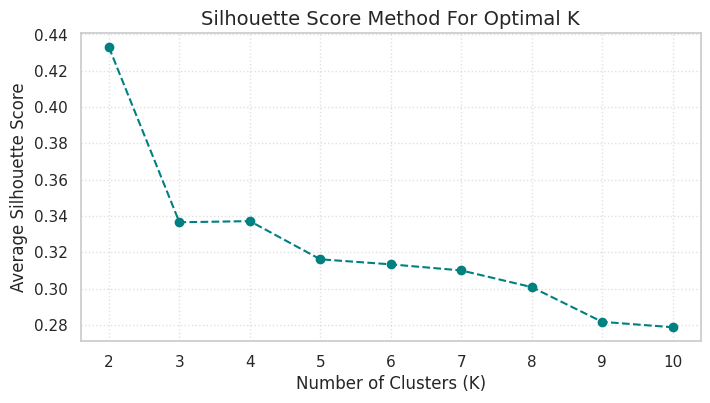

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of clusters to evaluate
k_range = range(2, 11)  # Silhouette score requires at least 2 clusters

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)

    # Calculate average silhouette score across all samples
    score = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"For n_clusters = {k}, the average silhouette score is: {score:.4f}")

# Plotting Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='teal', linestyle='--')
plt.title('Silhouette Score Method For Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

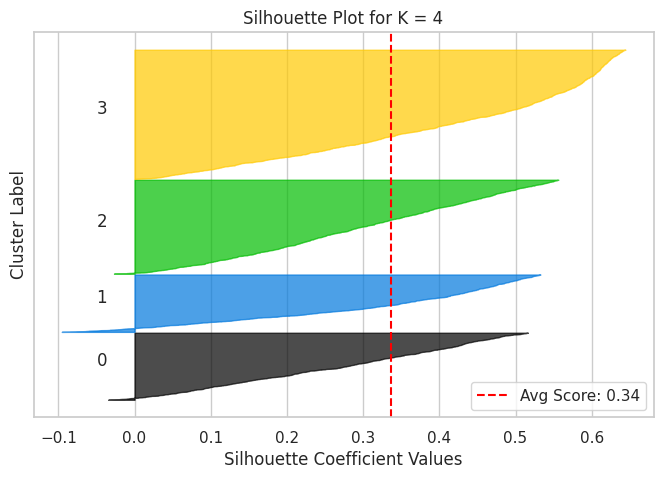

In [42]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

def plot_silhouette_analysis(X, n_clusters):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    avg_score = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 for the 0-samples spacing

    # Vertical line for average silhouette score of all the values
    ax.axvline(x=avg_score, color="red", linestyle="--", label=f'Avg Score: {avg_score:.2f}')

    ax.set_title(f"Silhouette Plot for K = {n_clusters}")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")
    ax.set_yticks([])  # Clear y-axis ticks
    ax.legend()
    plt.show()

# Run the detailed plot for 4 clusters
plot_silhouette_analysis(rfm_scaled, n_clusters=4)

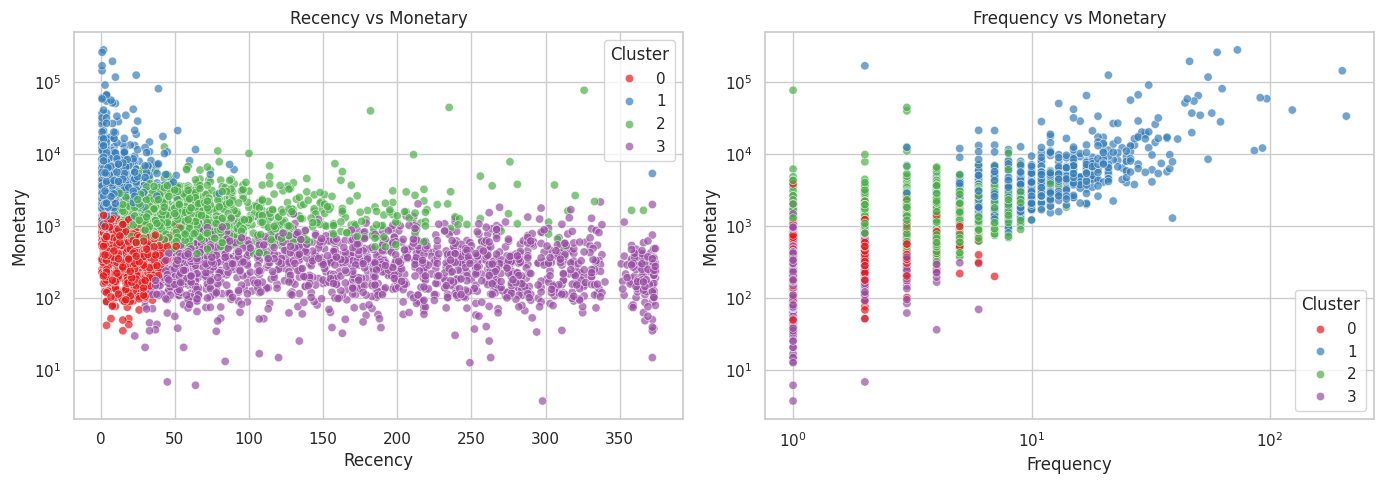

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combination 1: Recency vs Monetary
sns.scatterplot(
    ax=axes[0], data=rfm, x='Recency', y='Monetary',
    hue='Cluster', palette='Set1', alpha=0.7
)
axes[0].set_yscale('log')
axes[0].set_title('Recency vs Monetary')

# Combination 2: Frequency vs Monetary (Fixes checklist requirement)
sns.scatterplot(
    ax=axes[1], data=rfm, x='Frequency', y='Monetary',
    hue='Cluster', palette='Set1', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Frequency vs Monetary')

plt.tight_layout()
plt.show()

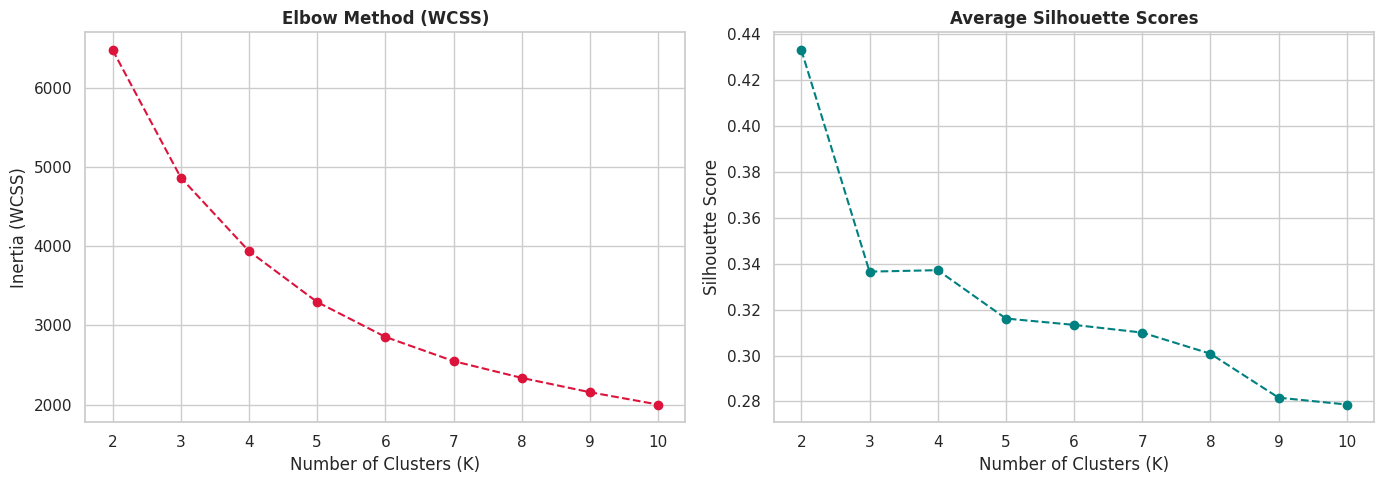

In [45]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  cluster_labels = kmeans.fit_predict(rfm_scaled)
  wcss.append(kmeans.inertia_)

  score = silhouette_score(rfm_scaled, cluster_labels)
  silhouette_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(2, 11), wcss, marker="o", color="crimson", linestyle="--"
)
axes[0].set_title("Elbow Method (WCSS)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(k_range, silhouette_scores, marker="o", color="teal", linestyle="--")
axes[1].set_title("Average Silhouette Scores", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

***SUMMARY***

---

**Cluster 0** (Low Recency, Low-Med Frequency, Med Spend) — "Recent / New Customers"

Strategy: Onboard with welcome emails, offer next-purchase incentives to boost repeat buy frequency.

**Cluster 1** (Low Recency, Very High Frequency, High Spend) — "Champions / VIPs"

Strategy: Loyalty rewards, early access to sales/new products, premium customer support.

**Cluster 2** (Moderate Recency, Moderate Frequency, Moderate Spend) — "At-Risk / Need Attention"

Strategy: Re-engagement campaigns, personalized recommendations based on past purchases.

**Cluster 3** (High Recency, Low Frequency, Low Spend) — "Hibernating / Lost Customers"

Strategy: Win-back discount codes; limit ad spend if non-responsive to save budget.



